In [6]:
from glob import glob
import cv2
import matplotlib.pyplot as plt
from subspaceadonnx import SubspaceAD

In [7]:
# Prepare directories with good images and images with defects
NORMAL_IMG_DIR = "datasets/transistor/train/good"
TARGET_IMG_DIR = "datasets/transistor/test/bent_lead"

In [15]:
model = SubspaceAD(
    "models/dinov3_vitsplus_224.onnx", # prepared model using export_onnx.py
    providers=["WebGpuExecutionProvider"]
)

### Fit model

In [16]:
normal_imgs = [cv2.imread(f) for f in glob(f"{NORMAL_IMG_DIR}/*.png")]
model.fit(normal_imgs)  # pass directory containing images or list[np.ndarray]

Extracting features:   0%|          | 0/213 [00:00<?, ?it/s]

Fitting PCA on 41748 patch tokens with feature dim 384.


Calibrating anomaly-map scale:   0%|          | 0/213 [00:00<?, ?it/s]

Anomaly-map scale calibrated: fit_max=0.0299404, scale=16.6999, scaled_max=0.5


In [10]:
def visualize_anomaly_map(target_img, 
                          anomaly_map, 
                          image_score,
                          threshold=0.5):
    """
    target_img: BGR HWC
    anomaly_map: HW float32
    image_score: float
    threshold: float, anomaly_mapの閾値
    """
    plt.figure(figsize=(12, 4))
    fig, axs = plt.subplots(1, 4, figsize=(12, 4))
    axs[0].imshow(cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB))
    axs[0].set_title("Input Image")
    axs[1].imshow(anomaly_map, cmap="jet", vmin=0, vmax=1)
    axs[1].set_title(f"Anomaly Map (score={image_score:.2f})")
    axs[2].imshow(cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB))
    axs[2].imshow(anomaly_map, cmap="jet", alpha=0.5, vmin=0, vmax=1)
    axs[2].set_title("Overlay")
    axs[3].imshow(anomaly_map > threshold, cmap="gray")
    axs[3].set_title(f"Thresholded (>{threshold})")
    for ax in axs:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


<Figure size 1200x400 with 0 Axes>

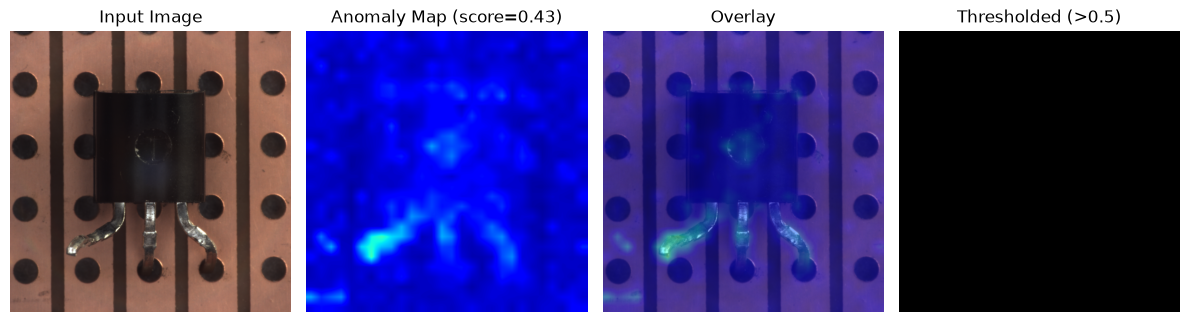

<Figure size 1200x400 with 0 Axes>

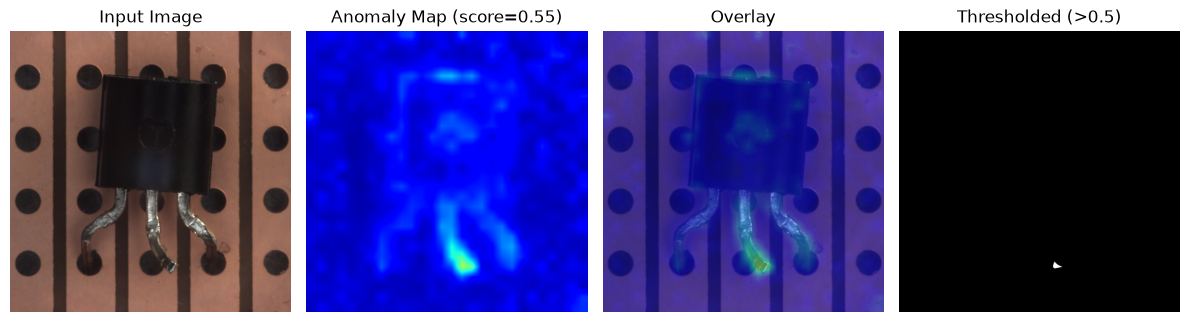

<Figure size 1200x400 with 0 Axes>

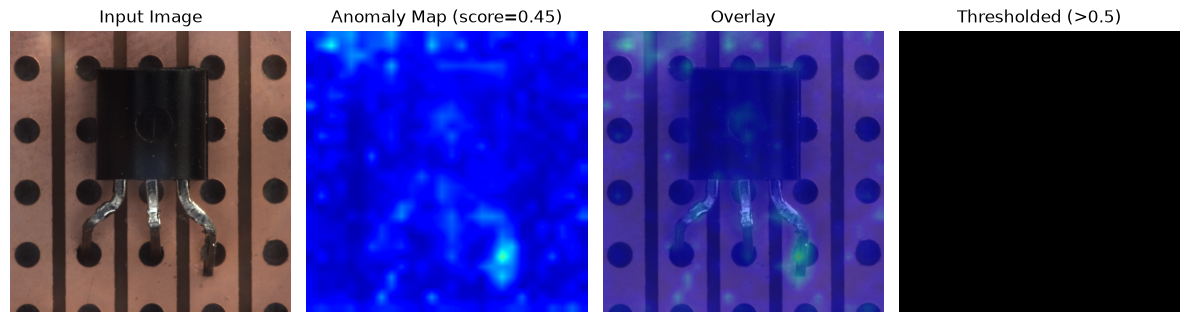

<Figure size 1200x400 with 0 Axes>

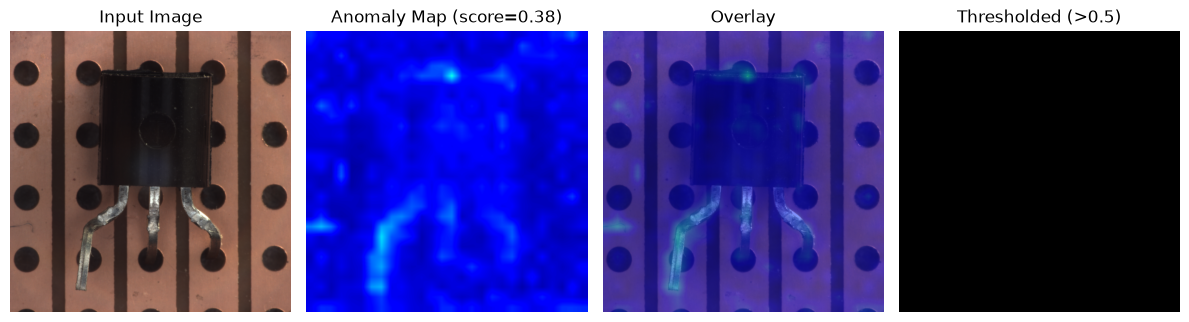

<Figure size 1200x400 with 0 Axes>

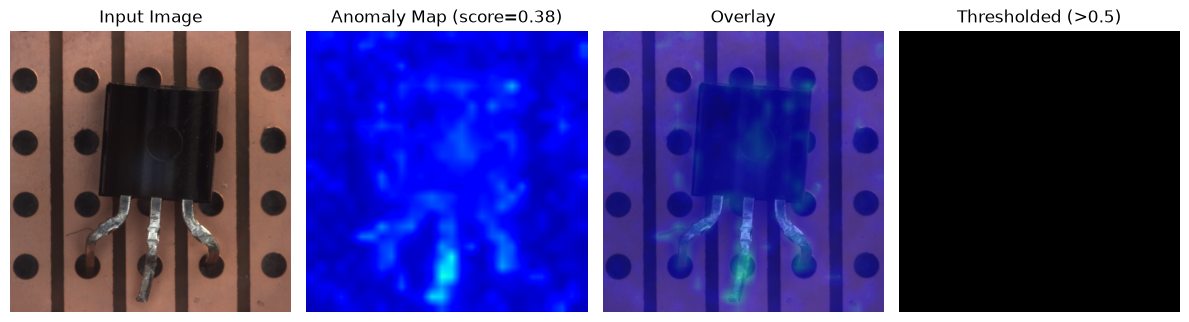

In [14]:
target_imgs = [cv2.imread(f) for f in glob(f"{TARGET_IMG_DIR}/*.png")]
for target_img in target_imgs[:5]:
    anomaly_map = model(target_img)
    image_score = model.image_score(target_img, method="max")
    visualize_anomaly_map(target_img, anomaly_map, image_score, threshold=0.5)

### Save & load fitted model

In [ ]:
# save PCA parameters to a file
pca_params = model.save_npz("models/pca_params.npz")
# load PCA parameters from a file
#model.load_npz("models/pca_params.npz")

### Run evaluation on MVTec Dataset

In [1]:
from subspaceadonnx import MVTecEvaluator

evaluator = MVTecEvaluator(
    dataset_root="datasets",
    dataset_names=["screw", "leather"],
    onnx_path="models/dinov3_vitsplus_224.onnx",
    providers=["WebGpuExecutionProvider"]
)
result = evaluator.evaluate()
for key, v in result.items():
    print(f"{key}: {v}")

[MVTec 1/2][screw] Start fitting (320imgs)


Extracting features:   0%|          | 0/320 [00:00<?, ?images/s]

Fitting PCA on 62720 patch tokens with feature dim 384.


Calibrating anomaly-map scale:   0%|          | 0/320 [00:00<?, ?images/s]

Anomaly-map scale calibrated: fit_max=0.0340268, scale=14.6943, scaled_max=0.5
[MVTec 1/2][screw] Training completed


...

Fitting PCA on 48020 patch tokens with feature dim 384.


Calibrating anomaly-map scale:   0%|          | 0/245 [00:00<?, ?images/s]

Anomaly-map scale calibrated: fit_max=0.0292797, scale=17.0767, scaled_max=0.5
[MVTec 2/2][leather] Training completed


[MVTec 2/2][leather] Inference:   0%|          | 0/124 [00:00<?, ?images/s]

[MVTec 2/2][leather] Start evaluation
[MVTec 2/2][leather] Evaluation completed (image AUROC=1.0000, pixel AUROC=0.9889)
date: 2026-07-04 12:33:02
description: dinov3_vitsplus_224
datasets: screw;leather
img_auroc: 0.8695429391268703
img_aupr: 0.9474392008091153
seg_auroc: 0.9796654552299986
seg_pro: 0.9240305759032195
